In [1]:
%load_ext autoreload
%autoreload 2

In [52]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import metrics
from modules import read_timeseries as read
from modules import ADCP_quality_flagging as custom
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

### Reading and converting files

In [3]:
# reading files
base_dir = Path(r'C:\Users\karoa\MOHID_internship\MOHID_single_domain\res')

folders = ['Run1', 'Run2', 'Run3']
name = '36_17' 

all_results = {folder: read.read_files(folder, name, base_dir) for folder in folders}

# converting to dataarray

vel_u = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_U')
vel_v = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_V')
vel_modulus = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_modulus')
vel_dir = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_direction')

### Plotting velocity profiles

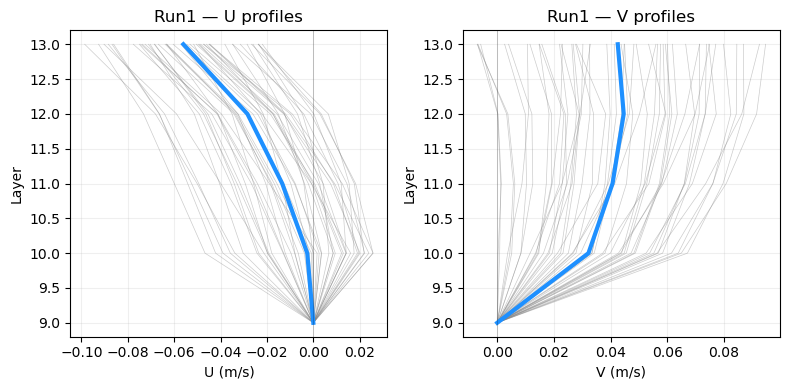

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
custom.plot_profiles(vel_u,
                     range_coord='layer',
                     range_slice=(9,13),        
                     xlabel='U (m/s)',
                     ylabel='Layer',
                     title='Run1 — U profiles',
                     mean_color='blue',
                     ax=axes[0])
custom.plot_profiles(vel_v,
                     range_coord='layer',
                     range_slice=(9,13),        
                     xlabel='V (m/s)',
                     ylabel='Layer',
                     title='Run1 — V profiles',
                     mean_color='blue',
                     ax=axes[1])
plt.show()

### Calculating metric

In [62]:
all_results['Run1'][13]

,velocity_U,velocity_V,velocity_W,velocity_modulus,velocity_direction,water_level,OpenPoint,salinity,temperature
date,,,,,,,,,
2023-01-13 01:00:00,-0.023770,-0.006923,0.000187,0.024757,253.762571,1.150747,1.0,36.971967,21.197094
2023-01-13 02:00:00,-0.034824,-0.005837,0.000181,0.035309,260.484148,1.437710,1.0,36.972197,21.196969
2023-01-13 03:00:00,-0.049697,0.010654,0.000081,0.050826,282.099544,1.701964,1.0,36.972658,21.197686
2023-01-13 04:00:00,-0.063268,0.032870,-0.000041,0.071297,297.453381,1.874697,1.0,36.973833,21.201297
2023-01-13 05:00:00,-0.074434,0.056023,-0.000101,0.093161,306.967037,1.913497,1.0,36.975850,21.208166
2023-01-13 06:00:00,-0.077628,0.071423,-0.000140,0.105486,312.616115,1.808507,1.0,36.978071,21.215261
2023-01-13 07:00:00,-0.073728,0.077140,-0.000170,0.106707,316.295373,1.583516,1.0,36.979758,21.219481
2023-01-13 08:00:00,-0.066838,0.071421,-0.000141,0.097818,316.898867,1.291645,1.0,36.980543,21.219444
2023-01-13 09:00:00,-0.060438,0.060087,-0.000071,0.085224,314.833326,1.002119,1.0,36.980561,21.215938


In [53]:
metrics.compare_vs_reference_df(all_results['Run1'][13], all_results['Run1'][13], metrics.rmse, columns=['velocity_V'])

velocity_V    0.0
Name: rmse, dtype: float64

In [64]:
ADCP_test = pd.read_csv(r'C:/Users/karoa/MOHID_internship/MOHID_model_workflow/data/calibration/ADCP_calibration_test.csv')
ADCP_test = ADCP_test.set_index('date')
ADCP_test

,velocity_U,velocity_V
date,,
2023-01-13 14:00:00,-0.009620,0.132774
2023-01-13 15:00:00,0.020955,0.046804
2023-01-13 16:00:00,0.006534,-0.161644
2023-01-13 17:00:00,0.025614,-0.220084
2023-01-13 18:00:00,-0.007432,-0.186023
...,...,...
2023-02-23 05:00:00,0.083181,-0.460826
2023-02-23 06:00:00,0.032002,-0.457428
2023-02-23 07:00:00,0.012353,-0.318638


In [ ]:
compare_vs_reference_df(ADCP_test, ADCP_test, metrics.rmse, columns=['velocity_U'])

velocity_U    0.0
Name: rmse, dtype: float64

In [94]:
model_output = all_results['Run1'][13].loc['2023-01-14':'2023-01-15']
ADCP_output = ADCP_test.loc['2023-01-14':'2023-01-15']

model_output.index = pd.to_datetime(model_output.index)
ADCP_output.index = pd.to_datetime(ADCP_output.index)

In [95]:
compare_vs_reference_df(model_output, ADCP_output, metrics.rmse, columns=['velocity_U'])

velocity_U    0.058384
Name: rmse, dtype: float64